## The project of stock predicting
NAME = "Charon Tang"

COLLABORATORS = "Charon Tang"


### Get started: set up the environment 

In [ ]:
from pathlib import Path
import sys

if "google.colab" in sys.modules:
    if not Path("/content/STOCK_PREDICTION").exists():
        !git clone https://github.com/CharonWTang/STOCK_PREDICTION.git
    %cd /content/STOCK_PREDICTION
    !git pull
    PROJECT_ROOT = Path("/content/STOCK_PREDICTION")
else:
    PROJECT_ROOT = Path(".")   

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "Data" / "train"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("tools.py exists =", (PROJECT_ROOT / "tools.py").exists())

/content/STOCK_PREDICTION
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 1), reused 3 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 7.39 KiB | 7.39 MiB/s, done.
From https://github.com/CharonWTang/STOCK_PREDICTION
   1f4ba3b..d0cce25  main       -> origin/main
Updating 1f4ba3b..d0cce25
Fast-forward
 Charon_Final.ipynb | 1753 +++-------------------------------------------------
 1 file changed, 80 insertions(+), 1673 deletions(-)
PROJECT_ROOT = /content/STOCK_PREDICTION
DATA_DIR = /content/STOCK_PREDICTION/Data/train
tools.py exists = True


In [ ]:
# all required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tools import *


In [ ]:
## Import keras; set backend

import os
os.environ["KERAS_BACKEND"] = "tensorflow" # torch

import keras

print(f"Keras version {keras.__version__}, backend: {keras.backend.backend()}")

from keras.utils import plot_model

if keras.backend.backend() ==  "tensorflow":
    import tensorflow as tf
    print(f"TensorFlow version {tf.__version__}")
    from tensorflow.keras import layers
    from sklearn.metrics import classification_report, confusion_matrix
elif keras.backend.backend() ==  "torch":
    import torch
    print(f"PyTorch version {torch.__version__}")


Keras version 3.13.2, backend: tensorflow
TensorFlow version 2.19.0


### At the begining of the soloving the problem: Defining
#### 1. Model type: choose classification task
#### Reason:

* From a practical perspective, directly forecasting the exact next-day stock return is extremely difficult because returns are noisy and highly unpredictable.
* In real trading, predicting the direction of movement is often more useful than predicting the exact numeric return. Knowing whether the stock is likely to go up, down, or stay roughly unchanged can already support trading decisions.
* A classification setup also makes the evaluation more interpretable. Compared with regression, it is easier to understand whether the model is making correct directional predictions.

#### 2. For Performance Metric
Since the classification of the task I choose to be Up/ Down/ Keep, I will use Macro F1-score as the primary indicator. I also include a confusion matrix to examine which types of directional errors the model makes.

#### 3. Model selection
I will primary use RNN and LSTM as the the main model, as the model involves time-series

## Get the data

In [ ]:
# loading the data

AAPL_data = pd.read_csv(DATA_DIR / 'AAPL.csv')
# set the date as the index
# parse Dt to real datetime, then set index
AAPL_data['Dt'] = pd.to_datetime(AAPL_data['Dt'], format='%Y-%m-%d', errors='coerce')
AAPL_data = AAPL_data.dropna(subset=['Dt']).sort_values('Dt').drop_duplicates(subset='Dt')
AAPL_data.set_index('Dt', inplace=True)
AAPL_data.head()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
Dt,,,,,,,,
2000-01-03,3.4785,111.938,0.0,1.0,112.500,101.688,104.8750,133949200.0
2000-01-04,3.1852,102.500,0.0,1.0,110.625,101.188,108.2500,128094400.0
2000-01-05,3.2318,104.000,0.0,1.0,110.563,103.000,103.7500,194580400.0
2000-01-06,2.9521,95.000,0.0,1.0,107.000,95.000,106.1183,191993200.0
2000-01-07,3.0920,99.500,0.0,1.0,101.000,95.500,96.5000,115183600.0


## Get the return of the stock, which is the target
I use the adj close to get the return, as this avoid the influence of event of divident giving and stock spliting

In [ ]:
# get the return of the stock
AAPLReturn = AAPL_data['Adj Close'].pct_change()
AAPLReturn.head()

,Adj Close
Dt,
2000-01-03,NaN
2000-01-04,-0.084318
2000-01-05,0.014630
2000-01-06,-0.086546
2000-01-07,0.047390


In [ ]:
# get little understanding of the data
AAPL_data.describe()

,Adj Close,Close,Div,Factor,High,Low,Open,Volume
count,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4.277000e+03
mean,34.065846,170.450354,0.001999,1.001870,172.424040,168.407568,170.528689,1.299660e+08
std,36.698987,173.484604,0.031011,0.094251,174.989551,171.934671,173.604272,9.970883e+07
min,0.815400,13.120000,0.000000,1.000000,13.190000,12.720000,12.990000,9.835000e+06
25%,3.115300,39.759000,0.000000,1.000000,40.260000,39.030000,39.530000,6.363350e+07
50%,16.948300,106.745000,0.000000,1.000000,108.360000,105.200000,106.959000,1.016484e+08
75%,62.413600,222.250000,0.000000,1.000000,224.980000,217.890000,220.010000,1.679636e+08
max,122.771400,702.100000,0.570000,7.000000,705.070000,699.570000,702.410000,1.855410e+09


In [ ]:
AAPL_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4277 entries, 2000-01-03 to 2016-12-30
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  4277 non-null   float64
 1   Close      4277 non-null   float64
 2   Div        4277 non-null   float64
 3   Factor     4277 non-null   float64
 4   High       4277 non-null   float64
 5   Low        4277 non-null   float64
 6   Open       4277 non-null   float64
 7   Volume     4277 non-null   float64
dtypes: float64(8)
memory usage: 300.7 KB


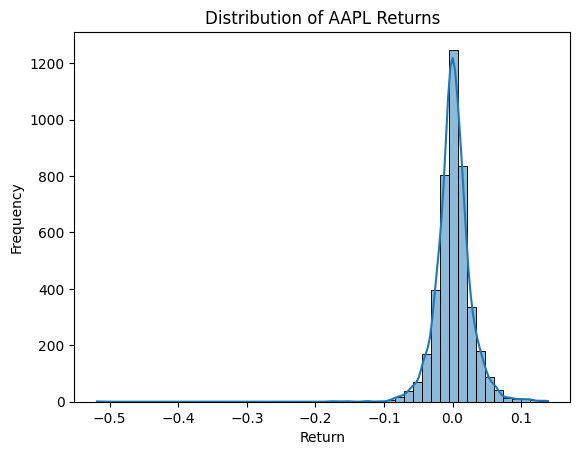

In [ ]:
# get the distribution of the return
import matplotlib.pyplot as plt
import seaborn as sns   
sns.histplot(AAPLReturn.dropna(), bins=50, kde=True)
plt.title('Distribution of AAPL Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# there is a very long tail in the distribution, is this a error in data or not? Check it.
AAPLReturn[AAPLReturn < -0.3]


,Adj Close
Dt,
2000-09-29,-0.518677


Already check the news, this is the real market data.
So the AAPL stock data, is clean and no need for other proprocess

## Get the train/validation/train split
This time only for AAPL data itself

But before the split, some decision have to do
* The window of date for each training sample: I will first set it to 1 year. But I will set the function flexiable to adjust the window
* The data arrange: 0.15 for validation, 0.15 for training, and in order to get the max use of the data, so I will use a window just slide through to get the data

In [ ]:
# get the data into three part: up, down and flat

x_train, y_train, x_val, y_val, x_test, y_test = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size = 252, add_transformed_features=0, target_mode="raw", return_index=False)

In [ ]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape) 
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (2816, 252, 8)
y_train shape: (2816,)
x_val shape: (603, 252, 8)
y_val shape: (603,)
x_test shape: (605, 252, 8)
y_test shape: (605,)


### Exploratory Data Analysis

In [ ]:
# using -0.01 as down threshold and 0.01 as up threshold, get the category of the return
y_train_cat = np.where(y_train < -0.01, 0, np.where(y_train > 0.01, 2, 1))
y_val_cat = np.where(y_val < -0.01, 0, np.where(y_val > 0.01, 2, 1))
y_test_cat = np.where(y_test < -0.01, 0, np.where(y_test > 0.01, 2, 1))   

# get the ratio of the three categories in the training set
unique, counts = np.unique(y_train_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Training set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_train_cat)*100:.2f}%")

unique, counts = np.unique(y_val_cat, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Validation set category distribution:")
for category, count in category_counts.items():
    print(f"Category {category}: {count} samples, {count/len(y_val_cat)*100:.2f}%")

Training set category distribution:
Category 0: 810 samples, 28.76%
Category 1: 1061 samples, 37.68%
Category 2: 945 samples, 33.56%
Validation set category distribution:
Category 0: 127 samples, 21.06%
Category 1: 322 samples, 53.40%
Category 2: 154 samples, 25.54%


There is a change in the distribution, but this is kinda acceptable


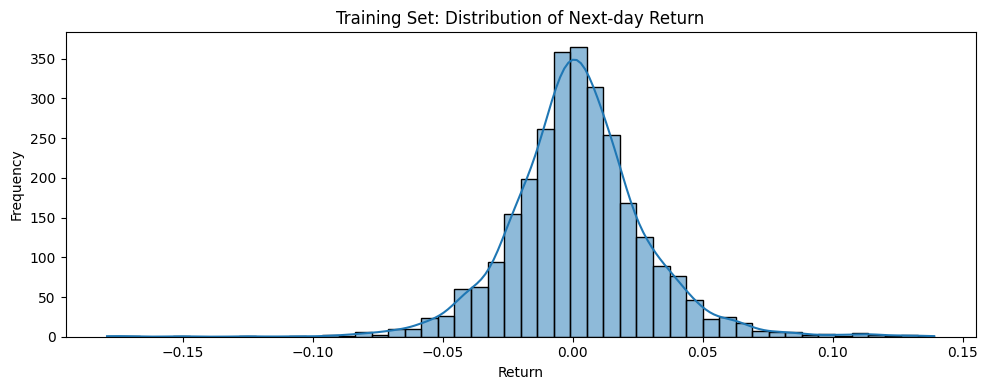

Top correlated last-day features with Return:
Volume       0.009736
Factor      -0.007064
Adj Close   -0.004444
Close       -0.003183
High        -0.002762
Open        -0.002670
Low         -0.002300
Div               NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


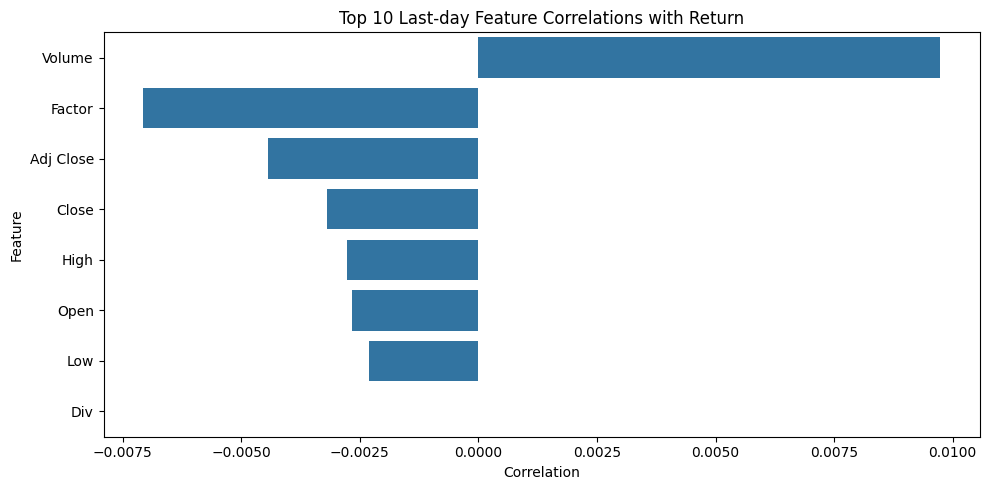

Top correlated window-summary features with Return:
Volume_min       -0.019784
Factor_max        0.012703
Factor_mean       0.012703
Factor_std        0.012703
Volume_mean      -0.010652
Adj Close_std    -0.007400
Adj Close_max    -0.004203
Volume_std        0.004007
Adj Close_mean   -0.003988
High_std          0.003846
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


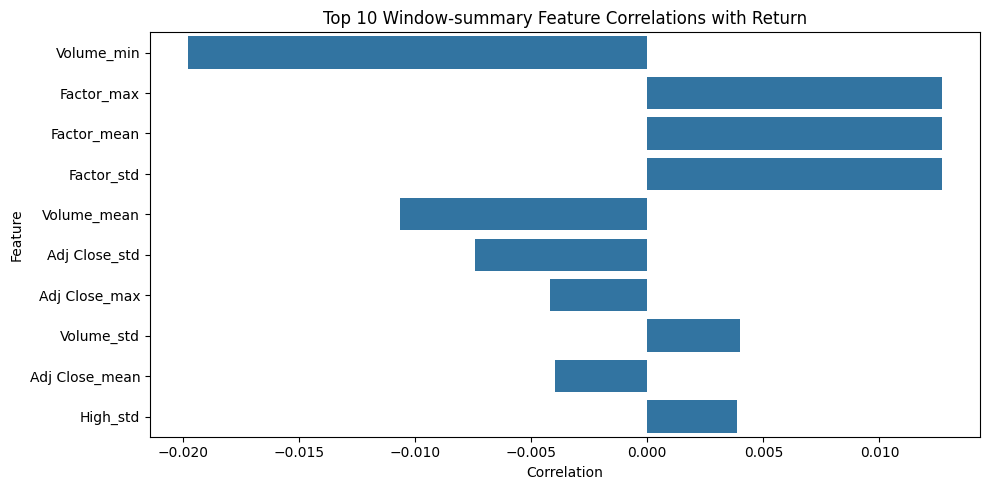

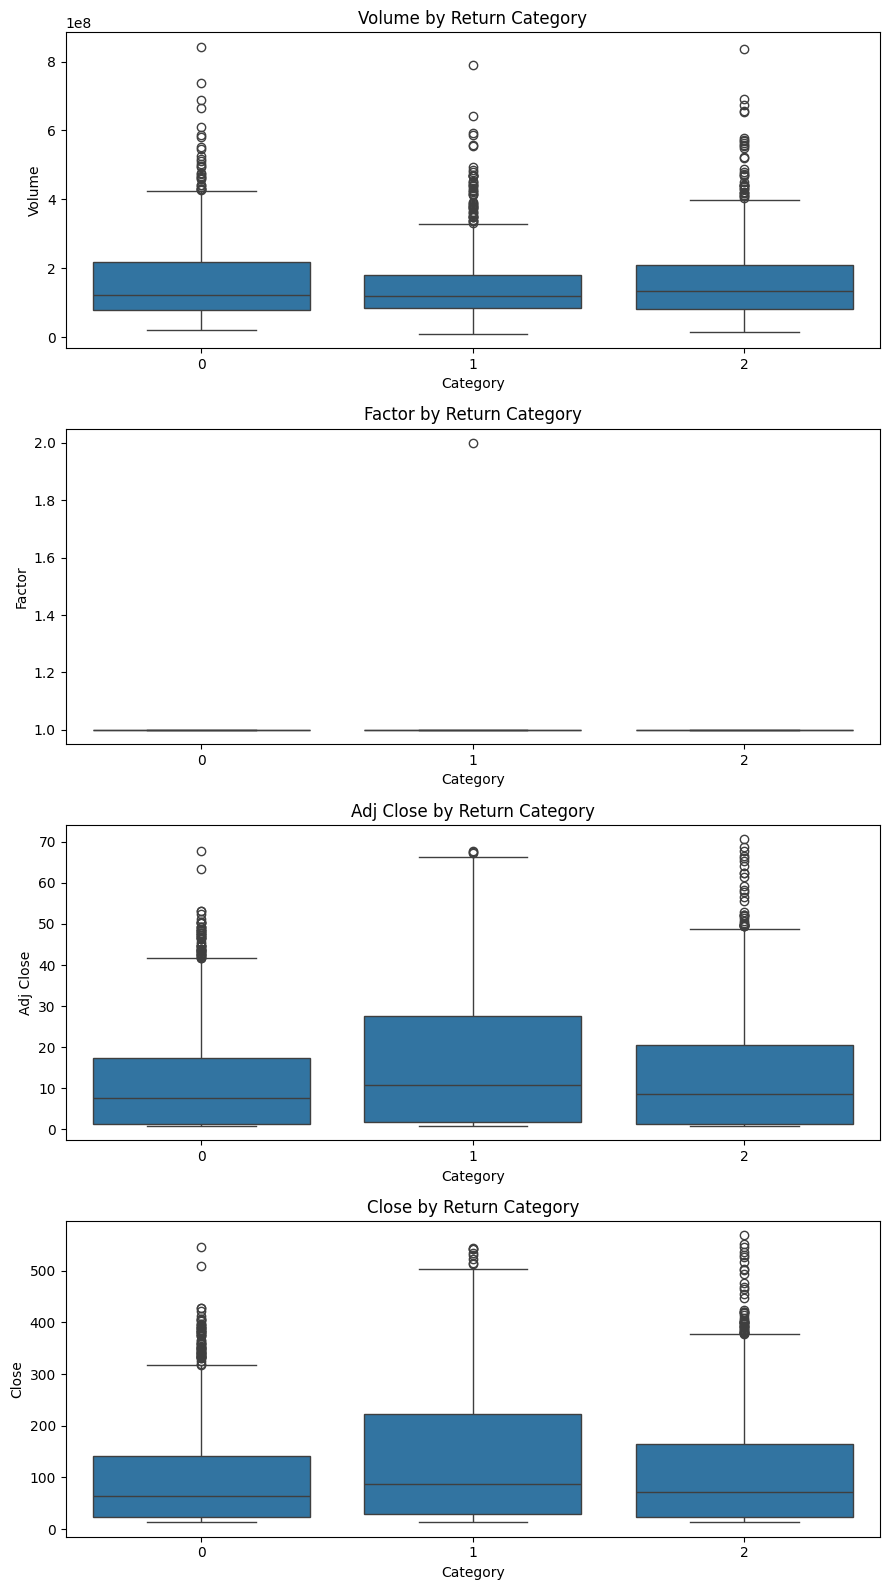

In [ ]:
# EDA using train data only


# feature names: keep the same order as single_stock_split
feature_names = AAPL_data.columns.tolist()

# use only train set
X_last = pd.DataFrame(x_train[:, -1, :], columns=feature_names)
y = pd.Series(y_train, name="Return")

# 1) distribution of target in train set
plt.figure(figsize=(10, 4))
sns.histplot(y, bins=50, kde=True)
plt.title("Training Set: Distribution of Next-day Return")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) correlation of last-day features with target
corr_last = X_last.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top correlated last-day features with Return:")
print(corr_last.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_last.head(10).values, y=corr_last.head(10).index, orient="h")
plt.title("Top 10 Last-day Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3) window-level summary features
X_mean = pd.DataFrame(x_train.mean(axis=1), columns=[f"{c}_mean" for c in feature_names])
X_std = pd.DataFrame(x_train.std(axis=1), columns=[f"{c}_std" for c in feature_names])
X_min = pd.DataFrame(x_train.min(axis=1), columns=[f"{c}_min" for c in feature_names])
X_max = pd.DataFrame(x_train.max(axis=1), columns=[f"{c}_max" for c in feature_names])

summary_df = pd.concat([X_mean, X_std, X_min, X_max], axis=1)
corr_summary = summary_df.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)

print("Top correlated window-summary features with Return:")
print(corr_summary.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_summary.head(10).values, y=corr_summary.head(10).index, orient="h")
plt.title("Top 10 Window-summary Feature Correlations with Return")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 4) compare feature behavior for up / down / flat
top_feats = corr_last.head(4).index.tolist()
fig, axes = plt.subplots(len(top_feats), 1, figsize=(9, 4 * len(top_feats)))
if len(top_feats) == 1:
    axes = [axes]

for ax, col in zip(axes, top_feats):
    sns.boxplot(x=y_train_cat, y=X_last[col], ax=ax)
    ax.set_title(f"{col} by Return Category")
    ax.set_xlabel("Category")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

For the original data, it barely shows any prediction power.
First we see the if there is some magic from this orignal data's deep learning model. Get some baseline.
Then, we try: transfer of the data maybe helpful? Get some more transformation for data


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 1.0988 - macro_f1: 0.3642 - val_loss: 1.0263 - val_macro_f1: 0.2545
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0841 - macro_f1: 0.3656 - val_loss: 1.0400 - val_macro_f1: 0.2723
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0803 - macro_f1: 0.3809 - val_loss: 1.0290 - val_macro_f1: 0.2443
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0774 - macro_f1: 0.3624 - val_loss: 1.0151 - val_macro_f1: 0.2375
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0748 - macro_f1: 0.3887 - val_loss: 1.0322 - val_macro_f1: 0.2366
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0738 - macro_f1: 0.3780 - val_loss: 1.0292 - val_macro_f1: 0.2634
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0789 - macro_f1: 0.3882 - val_loss: 1.0622 - val_macro_f1: 0.2461
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0737 - macro_f1: 0.3783 - val_loss: 1.0363 - val_m

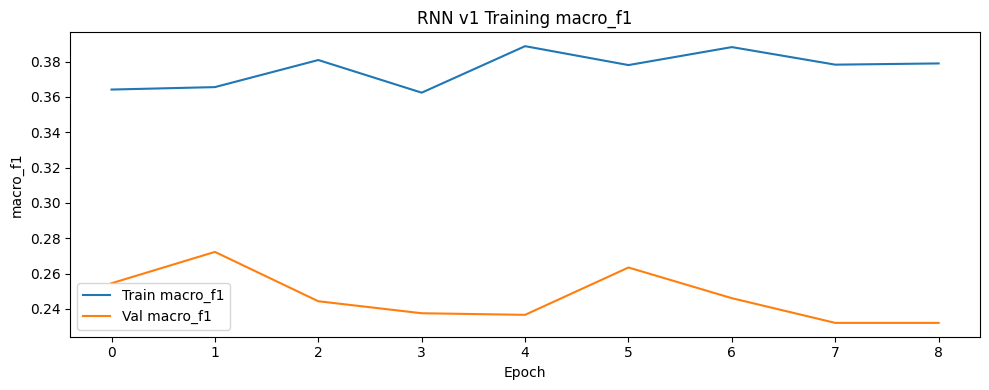

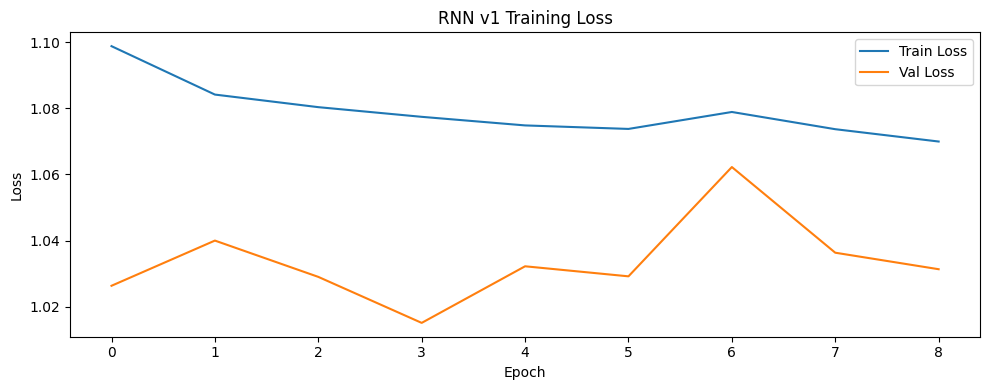

In [ ]:
# RNN baseline for the 3-class direction task
# labels are already in {0, 1, 2} from split
x_train, y_train, x_val, y_val, x_test, y_test = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size = 252, add_transformed_features=0, target_mode="direction_3class", return_index=False)
y_train_rnn = y_train
y_val_rnn = y_val
y_test_rnn = y_test

# Scale each feature using statistics from the training set only
train_mean = x_train.mean(axis=(0, 1), keepdims=True)
train_std = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn = (x_train - train_mean) / train_std
x_val_rnn = (x_val - train_mean) / train_std
x_test_rnn = (x_test - train_mean) / train_std

num_classes = 3
input_shape = x_train_rnn.shape[1:]

keras.backend.clear_session()

rnn_model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.1),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes)],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = rnn_model.fit(
    x_train_rnn,
    y_train_rnn,
    validation_data=(x_val_rnn, y_val_rnn),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

# direct validation evaluation helper
rnn_results = evaluate_keras_model_on_validation(
    model=rnn_model,
    history=history,
    x_val=x_val_rnn,
    y_val_cat=y_val_rnn,
    prefix="v1",
)


Based on the F1 and confusion matrix, the biggest problem right now is model just try to predict most of the result to be flat, rather than guess whether there is a up or down. So the next improvement I would like to do is to design a loss function really meet my requirement. Not just give a flat pridict, but make prediction on up or down.

My idea of improvement of loss function:
* Punish model a little bit when making flat prediction.
* No punish if the result is flating while predicting up or down
* Severily punish the model is make down prediction when down or make up prediction when up


Epoch 1/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 2.5697 - macro_f1: 0.2757 - val_loss: 2.2502 - val_macro_f1: 0.1412 - learning_rate: 7.0000e-04
Epoch 2/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 2.5424 - macro_f1: 0.2529 - val_loss: 2.2460 - val_macro_f1: 0.1356 - learning_rate: 7.0000e-04
Epoch 3/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.5449 - macro_f1: 0.2408 - val_loss: 2.2561 - val_macro_f1: 0.1410 - learning_rate: 7.0000e-04
Epoch 4/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.5327 - macro_f1: 0.2530 - val_loss: 2.2838 - val_macro_f1: 0.1358 - learning_rate: 7.0000e-04
Epoch 5/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.5499 - macro_f1: 0.2410 - val_loss: 2.2598 - val_macro_f1: 0.1356 - learning_rate: 7.0000e-04
Epoch 6/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.5335 - macro_f1: 0.1975 - val_loss: 2.2559 - val_macro_f1: 0.1316 - learning_rate: 3.5000e-04
Epoch 7/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.5205 - m

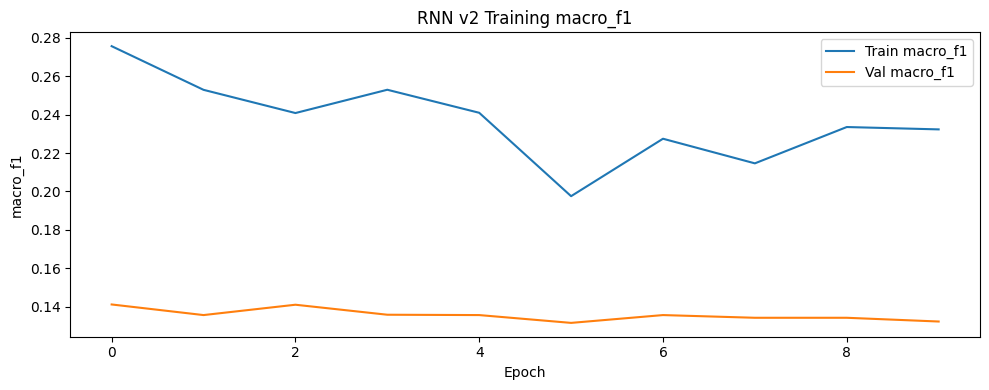

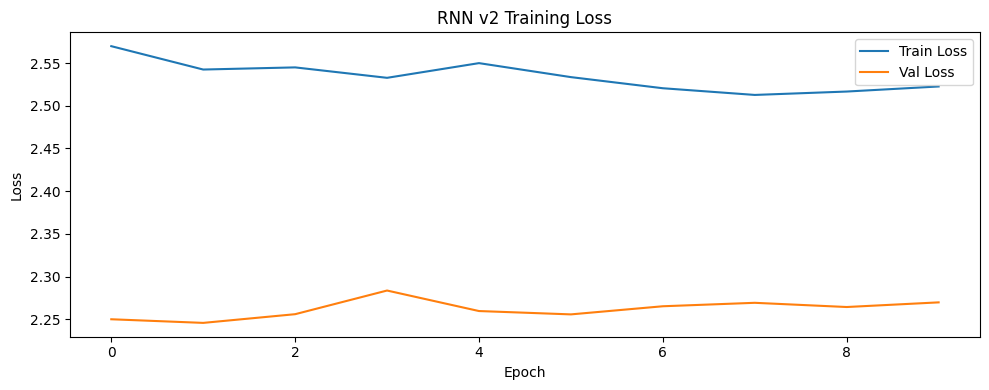

In [ ]:
# New model (appended): deeper RNN with custom cost-sensitive loss

# labels are already in {0, 1, 2} from split
y_train_rnn_v2 = y_train
y_val_rnn_v2 = y_val

# train-only normalization
train_mean_v2 = x_train.mean(axis=(0, 1), keepdims=True)
train_std_v2 = x_train.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v2 = (x_train - train_mean_v2) / train_std_v2
x_val_rnn_v2 = (x_val - train_mean_v2) / train_std_v2

num_classes_v2 = 3
input_shape_v2 = x_train_rnn_v2.shape[1:]

keras.backend.clear_session()

rnn_model_v2 = keras.Sequential([
    layers.Input(shape=input_shape_v2),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v2, activation="softmax"),
])

# Custom cost matrix: rows=true [Down, Flat, Up], cols=pred [Down, Flat, Up]
loss_matrix_v2 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v2 = tf.constant(loss_matrix_v2, dtype=tf.float32)

def matrix_weighted_loss_v2(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v2)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v2)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v2 = 1.2
    return ce + lambda_cost_v2 * expected_cost

rnn_model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v2,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v2)],
)

callbacks_v2 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v2 = rnn_model_v2.fit(
    x_train_rnn_v2,
    y_train_rnn_v2,
    validation_data=(x_val_rnn_v2, y_val_rnn_v2),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v2,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v2 = evaluate_keras_model_on_validation(
    model=rnn_model_v2,
    history=history_v2,
    x_val=x_val_rnn_v2,
    y_val_cat=y_val_rnn_v2,
    prefix="v2",
)


To adjust for the loss function may be a good idea, but after trying different loss matrix, the biggest problem right now for the model is there is nothing for it to learn. 
Even after changing the loss matrix to stop the model to all predict flat, it then change to strategy that predicting everything in Up.

### Transform of data and expand the data

In [ ]:
# make the transformation of the data
# what is the potential informatiion within the data?

# some ideas:
# Returns
# Moving averages of return(e.g., 5-day, 20-day, 50-day)
# MACD  (one EMA minus another EMA)
# Volatility measures (e.g., rolling standard deviation of returns)
# Bolling bands (moving average plus/minus a multiple of rolling std)
# Relative Strength Index (RSI)
# SAR
# strat_cci 
# strat_arbr 
# pvi
# volume z-score
# return sign / streak

# here lets see the results of adding some of these features to the RNN model, and see if it can improve the performance
x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)


x_train_ext shape: (2782, 252, 29)
y_train_ext shape: (2782,)
x_val_ext shape: (596, 252, 29)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 29)
y_test_ext shape: (597,)


Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - loss: 2.5524 - macro_f1: 0.3033 - val_loss: 2.2739 - val_macro_f1: 0.2184 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 2.5077 - macro_f1: 0.2907 - val_loss: 2.2521 - val_macro_f1: 0.1586 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.4908 - macro_f1: 0.2928 - val_loss: 2.3046 - val_macro_f1: 0.1407 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 2.4586 - macro_f1: 0.2903 - val_loss: 2.2816 - val_macro_f1: 0.3206 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 2.4591 - macro_f1: 0.3105 - val_loss: 2.2543 - val_macro_f1: 0.2099 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 2.4455 - macro_f1: 0.2887 - val_loss: 2.2566 - val_macro_f1: 0.1851 - learning_rate: 3.5000e-04
Epoch 7/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.4125 - m

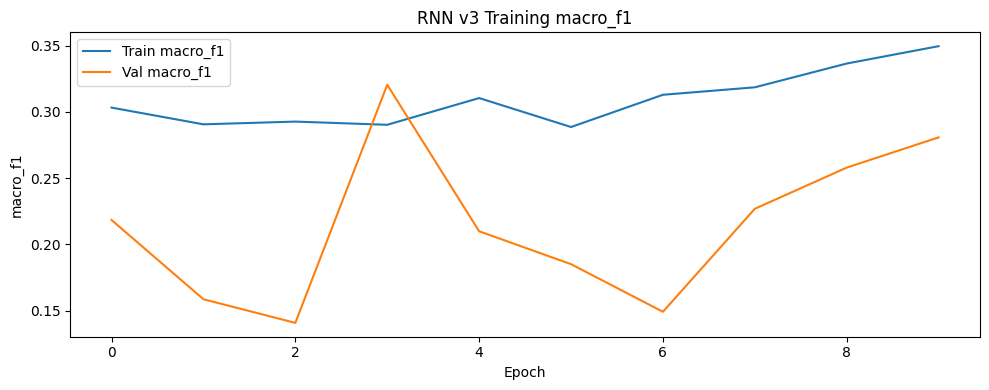

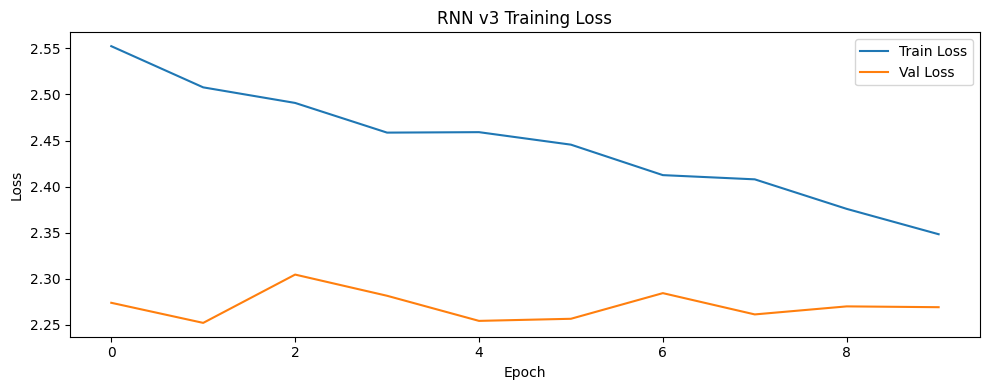

In [ ]:
# v3: same setup as v2, but trained on extended features (x_*_ext)

# labels are already in {0, 1, 2} from split
y_train_rnn_v3 = y_train_ext
y_val_rnn_v3 = y_val_ext

# train-only normalization
train_mean_v3 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v3 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v3 = (x_train_ext - train_mean_v3) / train_std_v3
x_val_rnn_v3 = (x_val_ext - train_mean_v3) / train_std_v3

num_classes_v3 = 3
input_shape_v3 = x_train_rnn_v3.shape[1:]

keras.backend.clear_session()

rnn_model_v3 = keras.Sequential([
    layers.Input(shape=input_shape_v3),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v3, activation="softmax"),
])

# Same cost matrix and weighted loss as v2
loss_matrix_v3 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v3 = tf.constant(loss_matrix_v3, dtype=tf.float32)

def matrix_weighted_loss_v3(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v3)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v3)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v3 = 1.2
    return ce + lambda_cost_v3 * expected_cost

rnn_model_v3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v3,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v3)],
)

callbacks_v3 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v3 = rnn_model_v3.fit(
    x_train_rnn_v3,
    y_train_rnn_v3,
    validation_data=(x_val_rnn_v3, y_val_rnn_v3),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v3,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v3 = evaluate_keras_model_on_validation(
    model=rnn_model_v3,
    history=history_v3,
    x_val=x_val_rnn_v3,
    y_val_cat=y_val_rnn_v3,
    prefix="v3",
)


I mean, at least the model start to make some judgement, which means that this may really helpful. Though the this model still try to guess everything as up, at lease make some try already.

x_train_ext shape: (2782, 252, 29)
y_train_ext shape: (2782,)
x_val_ext shape: (596, 252, 29)
y_val_ext shape: (596,)
x_test_ext shape: (597, 252, 29)
y_test_ext shape: (597,)
Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step - loss: 2.6071 - macro_f1: 0.2818 - val_loss: 2.2426 - val_macro_f1: 0.1858 - learning_rate: 7.0000e-04
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 2.5104 - macro_f1: 0.2835 - val_loss: 2.2307 - val_macro_f1: 0.2020 - learning_rate: 7.0000e-04
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 2.5002 - macro_f1: 0.2887 - val_loss: 2.2488 - val_macro_f1: 0.2565 - learning_rate: 7.0000e-04
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 2.4906 - macro_f1: 0.3019 - val_loss: 2.2295 - val_macro_f1: 0.2187 - learning_rate: 7.0000e-04
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 2.4718 - macro_f1: 0.3046 - val_loss: 2.2303 - val_macro_f1: 0.2816 - learning_rate: 7.0000e-04
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/st

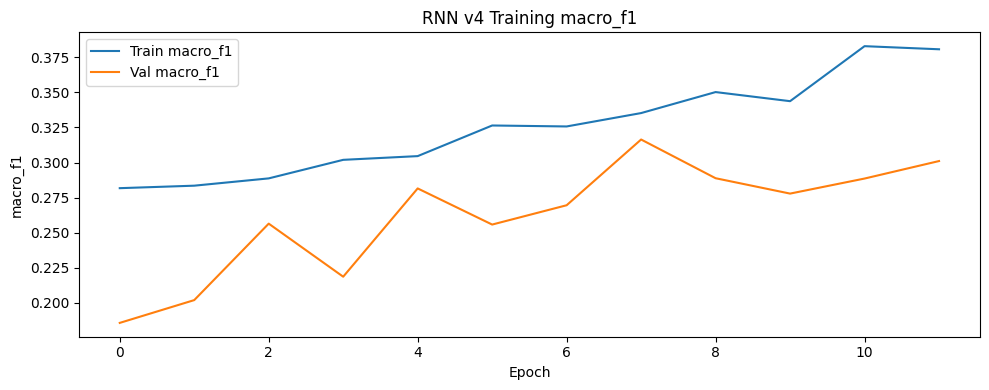

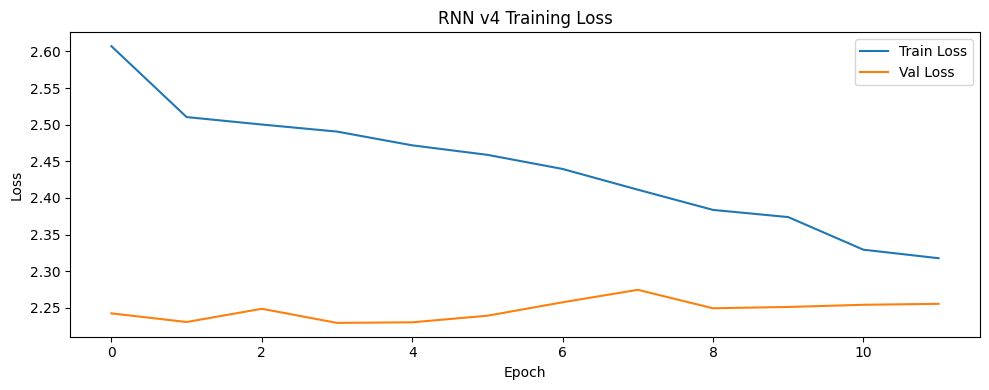

In [ ]:
# Only keep the original OHLCV features (no extended features) but use the same model architecture and training setup as v3, to see if the improvement in v3 is from the model/training or from the features.
x_train_ext, y_train_ext, x_val_ext, y_val_ext, x_test_ext, y_test_ext = single_stock_split(AAPL_data, AAPLReturn, train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=2, target_mode="direction_3class", return_index=False)

print("x_train_ext shape:", x_train_ext.shape)
print("y_train_ext shape:", y_train_ext.shape)
print("x_val_ext shape:", x_val_ext.shape) 
print("y_val_ext shape:", y_val_ext.shape)
print("x_test_ext shape:", x_test_ext.shape)
print("y_test_ext shape:", y_test_ext.shape)

# labels are already in {0, 1, 2} from split
y_train_rnn_v4 = y_train_ext
y_val_rnn_v4 = y_val_ext

# train-only normalization
train_mean_v4 = x_train_ext.mean(axis=(0, 1), keepdims=True)
train_std_v4 = x_train_ext.std(axis=(0, 1), keepdims=True) + 1e-8
x_train_rnn_v4 = (x_train_ext - train_mean_v4) / train_std_v4
x_val_rnn_v4 = (x_val_ext - train_mean_v4) / train_std_v4

num_classes_v4 = 3
input_shape_v4 = x_train_rnn_v4.shape[1:]

keras.backend.clear_session()

rnn_model_v4 = keras.Sequential([
    layers.Input(shape=input_shape_v4),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v4, activation="softmax"),
])

# Same cost matrix and weighted loss as v2
loss_matrix_v4 = np.array([
    [0.0, 3.0, 3.0],
    [0.0, 0.2, 0.0],
    [3.0, 3.0, 0.0],
], dtype=np.float32)
loss_matrix_tf_v4 = tf.constant(loss_matrix_v4, dtype=tf.float32)

def matrix_weighted_loss_v4(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v4)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v4)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v4 = 1.2
    return ce + lambda_cost_v4 * expected_cost

rnn_model_v4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v4,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v4)],
)

callbacks_v4 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v4 = rnn_model_v4.fit(
    x_train_rnn_v4,
    y_train_rnn_v4,
    validation_data=(x_val_rnn_v4, y_val_rnn_v4),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v4,
    verbose=1,
)

# direct validation evaluation helper
rnn_results_v4 = evaluate_keras_model_on_validation(
    model=rnn_model_v4,
    history=history_v4,
    x_val=x_val_rnn_v4,
    y_val_cat=y_val_rnn_v4,
    prefix="v4",
)


Almost no improvement, just struggle.

In [ ]:
from functools import reduce

# Now lets adding for information inside, let the model sturggele in higher demension ;)

# naive process, directly adding all feature in other stock

# Read all other stock files and merge them into one wide table on Dt
other_stock_paths = sorted((DATA_DIR).glob('*.csv'))
other_stock_paths = [p for p in other_stock_paths if p.stem != 'AAPL']

other_stock_tables = []
for stock_path in other_stock_paths:
    stock_name = stock_path.stem
    stock_df = pd.read_csv(stock_path)
    stock_df['Dt'] = pd.to_datetime(stock_df['Dt'])
    stock_df = stock_df.sort_values('Dt').drop_duplicates(subset='Dt')
    stock_df = stock_df.rename(columns={col: f'{stock_name}_{col}' for col in stock_df.columns if col != 'Dt'})
    other_stock_tables.append(stock_df)

other_stocks_big_table = reduce(lambda left, right: pd.merge(left, right, on='Dt', how='inner'), other_stock_tables)
other_stocks_big_table.set_index('Dt', inplace=True)

print('other_stocks_big_table shape:', other_stocks_big_table.shape)
other_stocks_big_table.head()

other_stocks_big_table shape: (4277, 184)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [ ]:
# get this big table into the same format as x_train, x_val, x_test, and then we can concatenate it with the original features for AAPL to train the model
x_train, y_train, x_val, y_val, x_test, y_test = multi_stock_split(AAPL_data, AAPLReturn, other_stocks_big_table,train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape) 
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (41, 252, 213)
y_train shape: (41,)
x_val shape: (8, 252, 213)
y_val shape: (8,)
x_test shape: (10, 252, 213)
y_test shape: (10,)


In [ ]:

# I can't directly use the merged data, as the missing data in the other stock will cause the number of samples to drop significantly, so I need to do some imputation for the missing data, and then train the model on the imputed data.
# So I have to check the the missing data first

start_dates = []

stock_names = sorted({col.split('_', 1)[0] for col in other_stocks_big_table.columns if '_' in col})

for stock in stock_names:
    stock_cols = [c for c in other_stocks_big_table.columns if c.startswith(f"{stock}_")]
    has_data = other_stocks_big_table[stock_cols].notna().any(axis=1)
    first_date = has_data[has_data].index.min() if has_data.any() else pd.NaT
    start_dates.append((stock, first_date, len(stock_cols)))

start_dates_df = pd.DataFrame(start_dates, columns=["Stock", "FirstAvailableDate", "NumFeatures"]).sort_values("FirstAvailableDate")
print(start_dates_df.to_string(index=False))

Stock FirstAvailableDate  NumFeatures
  SPY         2000-01-03            8
  XLU         2000-01-03            8
  XLP         2000-01-03            8
  XLK         2000-01-03            8
  XLI         2000-01-03            8
  XLF         2000-01-03            8
  XLE         2000-01-03            8
  XLB         2000-01-03            8
  XLV         2000-01-03            8
 NVDA         2000-01-03            8
  XLY         2000-01-03            8
 INTC         2000-01-03            8
  IBM         2000-01-03            8
 CSCO         2000-01-03            8
 ADBE         2000-01-03            8
 MSFT         2000-01-03            8
  ACN         2001-07-19            8
  CRM         2004-06-23            8
 GOOG         2004-08-19            8
   MA         2006-05-25            8
    V         2008-03-19            8
   FB         2012-05-18            8
 XLRE         2015-10-08            8


In [ ]:
# so as long as I delete  MA/V/FB/XLRE then the time is fine
deleted_stocks = {'MA', 'V', 'FB', 'XLRE'}

# only drop columns whose stock prefix is exactly in deleted_stocks
cols_to_drop = [
    col for col in other_stocks_big_table.columns
    if col.split('_', 1)[0] in deleted_stocks
]

other_stocks_big_table_dropped = other_stocks_big_table.drop(columns=cols_to_drop)

print("dropped columns:", len(cols_to_drop))
print("other_stocks_big_table_dropped shape:", other_stocks_big_table_dropped.shape)
other_stocks_big_table_dropped.head()

dropped columns: 32
other_stocks_big_table_dropped shape: (4277, 152)


,ACN_Adj Close,ACN_Close,ACN_Div,ACN_Factor,ACN_High,ACN_Low,ACN_Open,ACN_Volume,ADBE_Adj Close,ADBE_Close,...,XLV_Open,XLV_Volume,XLY_Adj Close,XLY_Close,XLY_Div,XLY_Factor,XLY_High,XLY_Low,XLY_Open,XLY_Volume
Dt,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.2747,65.563,...,31.000,246700.0,23.6030,30.125,0.0,1.0,31.0000,29.8590,31.000,212900.0
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.9094,60.063,...,30.188,35300.0,22.8930,29.219,0.0,1.0,29.8130,29.0310,29.688,177200.0
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.2042,61.250,...,29.781,137600.0,22.6114,28.859,0.0,1.0,29.3461,28.7190,29.344,124600.0
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.3283,61.750,...,29.313,50000.0,22.8685,29.188,0.0,1.0,29.4060,28.9991,29.047,135800.0
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0730,64.750,...,29.469,22100.0,23.9458,30.563,0.0,1.0,30.5630,29.5000,29.500,70000.0


In [ ]:
x_train, y_train, x_val, y_val, x_test, y_test = multi_stock_split(AAPL_data, AAPLReturn, other_stocks_big_table_dropped,train_size=0.7, val_size=0.15, test_size=0.15, window_size=252, add_transformed_features=1, target_mode="direction_3class", return_index=False)
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape) 
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (2004, 252, 181)
y_train shape: (2004,)
x_val shape: (429, 252, 181)
y_val shape: (429,)
x_test shape: (430, 252, 181)
y_test shape: (430,)


Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - loss: 2.5006 - macro_f1: 0.2619 - val_loss: 2.1141 - val_macro_f1: 0.1687 - learning_rate: 7.0000e-04
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.4561 - macro_f1: 0.3182 - val_loss: 2.1299 - val_macro_f1: 0.1440 - learning_rate: 7.0000e-04
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.4196 - macro_f1: 0.3073 - val_loss: 2.0941 - val_macro_f1: 0.1787 - learning_rate: 7.0000e-04
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.3891 - macro_f1: 0.3186 - val_loss: 2.1235 - val_macro_f1: 0.1356 - learning_rate: 7.0000e-04
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 2.3738 - macro_f1: 0.2967 - val_loss: 2.0985 - val_macro_f1: 0.1438 - learning_rate: 7.0000e-04
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.3783 - macro_f1: 0.3142 - val_loss: 2.1039 - val_macro_f1: 0.2803 - learning_rate: 7.0000e-04
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 2.3373 - 

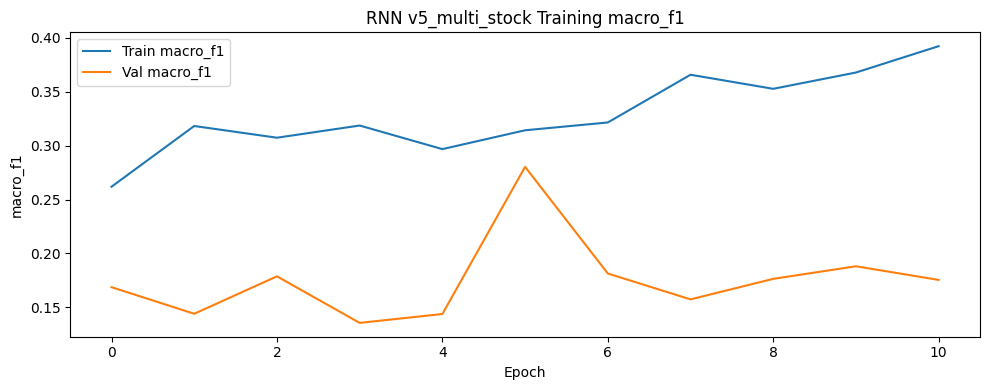

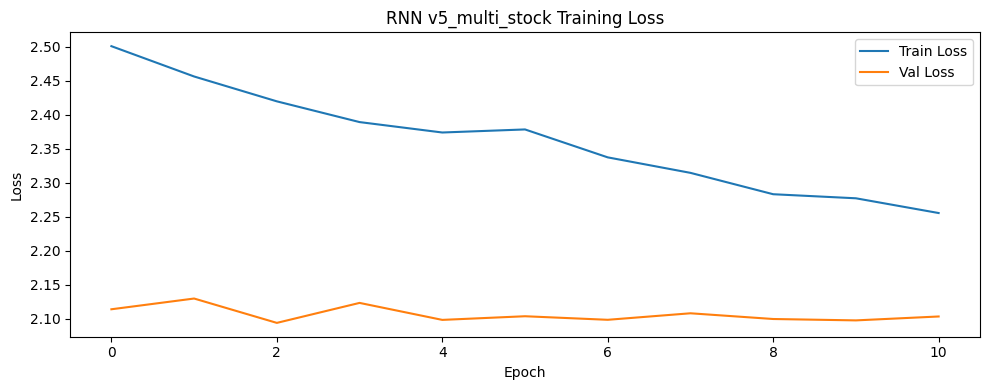

In [ ]:
# now still use RNN but see with more feature inside if there is magic

# v5: RNN on multi-stock features (same setup style as v3/v4)

# labels already in {0,1,2}
y_train_rnn_v5 = y_train
y_val_rnn_v5 = y_val
y_test_rnn_v5 = y_test

# train-only normalization
train_mean_v5 = x_train.mean(axis=(0, 1), keepdims=True)
train_std_v5 = x_train.std(axis=(0, 1), keepdims=True) + 1e-8

x_train_rnn_v5 = (x_train - train_mean_v5) / train_std_v5
x_val_rnn_v5 = (x_val - train_mean_v5) / train_std_v5
x_test_rnn_v5 = (x_test - train_mean_v5) / train_std_v5

num_classes_v5 = 3
input_shape_v5 = x_train_rnn_v5.shape[1:]

keras.backend.clear_session()

rnn_model_v5 = keras.Sequential([
    layers.Input(shape=input_shape_v5),
    layers.SimpleRNN(128, activation="tanh", return_sequences=True),
    layers.Dropout(0.25),
    layers.SimpleRNN(64, activation="tanh"),
    layers.Dropout(0.25),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes_v5, activation="softmax"),
])

# same cost-sensitive loss as before
loss_matrix_v5 = np.array([
    [0.0, 3.0, 3.0],  # true Down
    [0.0, 0.2, 0.0],  # true Flat
    [3.0, 3.0, 0.0],  # true Up
], dtype=np.float32)
loss_matrix_tf_v5 = tf.constant(loss_matrix_v5, dtype=tf.float32)

def matrix_weighted_loss_v5(y_true, y_pred):
    ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    y_true = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes_v5)
    cost_rows = tf.matmul(y_true_oh, loss_matrix_tf_v5)
    expected_cost = tf.reduce_sum(cost_rows * y_pred, axis=-1)
    lambda_cost_v5 = 1.2
    return ce + lambda_cost_v5 * expected_cost

rnn_model_v5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=matrix_weighted_loss_v5,
    metrics=[make_sparse_macro_f1_metric(num_classes=num_classes_v5)],
)

callbacks_v5 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
]

history_v5 = rnn_model_v5.fit(
    x_train_rnn_v5,
    y_train_rnn_v5,
    validation_data=(x_val_rnn_v5, y_val_rnn_v5),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_v5,
    verbose=1,
)

# validation evaluation
rnn_results_v5 = evaluate_keras_model_on_validation(
    model=rnn_model_v5,
    history=history_v5,
    x_val=x_val_rnn_v5,
    y_val_cat=y_val_rnn_v5,
    prefix="v5_multi_stock",
)


No magic...
So at least tell us if we don't transfer the origin model then it barely learns
Other possible helping solution:
1. Start transfer the original data of other stocks <-- try this first
2. Change model


In [ ]:
# since we want to transfer the data, we need to understand the data.
# the indicator of the market: SPY
SPY_data = other_stocks_big_table_dropped[other_stocks_big_table_dropped['symbol'] == 'SPY'].copy()
SPY_data.head()

In [ ]:
data = add_technical_features(data)

In [ ]:
# Rolling beta/alpha of AAPL vs SPY (no look-ahead)

# 1) load SPY
SPY_raw = pd.read_csv(DATA_DIR / "SPY.csv")
SPY_raw["Dt"] = pd.to_datetime(SPY_raw["Dt"], format="%Y-%m-%d", errors="coerce")
SPY_raw = SPY_raw.dropna(subset=["Dt"]).sort_values("Dt").drop_duplicates(subset="Dt").set_index("Dt")

# 2) daily returns
aapl_ret = AAPL_data["Adj Close"].pct_change().rename("AAPL_ret")
spy_ret = SPY_raw["Adj Close"].pct_change().rename("SPY_ret")

# 3) align by date
pair_ret = pd.concat([aapl_ret, spy_ret], axis=1, join="inner").dropna()

# 4) rolling OLS components (using only past window)
window = 252
rolling_cov = pair_ret["AAPL_ret"].rolling(window).cov(pair_ret["SPY_ret"])
rolling_var = pair_ret["SPY_ret"].rolling(window).var()
beta_raw = rolling_cov / (rolling_var + 1e-12)

mean_aapl = pair_ret["AAPL_ret"].rolling(window).mean()
mean_spy = pair_ret["SPY_ret"].rolling(window).mean()
alpha_raw = mean_aapl - beta_raw * mean_spy

# 5) shift(1): at time t, beta/alpha only use info up to t-1
pair_ret["beta_252"] = beta_raw.shift(1)
pair_ret["alpha_252"] = alpha_raw.shift(1)

# optional: merge to AAPL feature table
AAPL_data = AAPL_data.join(pair_ret[["beta_252", "alpha_252"]], how="left")

print(AAPL_data[["beta_252", "alpha_252"]].tail())
# ...existing code...